### Implemetation of SELF ATTENTION with TRAINABLE WEIGHTS

In [1]:
import torch
print("Pytorch version:", torch.__version__)


Pytorch version: 2.10.0+cu126


In [54]:
inputs = torch.tensor(
    [[0.43, 0.15, 0.89], # your     x^1
     [0.55, 0.87, 0.66], # journey  x^2
     [0.57, 0.85, 0.64], # starts   x^3
     [0.22, 0.58, 0.33], # with     x^4
     [0.77, 0.25, 0.10], # one      x^5
     [0.05, 0.80, 0.55]] # step     x^6
)

Let's define 3 variables:

- The 2nd Input element

- The input embedding size, d = 3

- The output_embedding size, d_out = 2

In [55]:
x_2 = inputs[1]

d_in = inputs.shape[1]

d_out = 2

In [68]:
torch.manual_seed(123)
W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_key = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

In [69]:
W_query

Parameter containing:
tensor([[0.2961, 0.5166],
        [0.2517, 0.6886],
        [0.0740, 0.8665]])

In [2]:

from IPython.display import Image

In [71]:
print("Query weight matrix:\n", W_query)

Query weight matrix:
 Parameter containing:
tensor([[0.2961, 0.5166],
        [0.2517, 0.6886],
        [0.0740, 0.8665]])


In [72]:
# Let's compute the multiplication for the query vector of the second word "journey" (x^2) as an example:

query_2 = x_2 @ W_query
print("Query vector for 'journey':\n", query_2)
key_2 = x_2 @ W_key
print("Key vector for 'journey':\n", key_2)
value_2 = x_2 @ W_value
print("Value vector for 'journey':\n", value_2)

Query vector for 'journey':
 tensor([0.4306, 1.4551])
Key vector for 'journey':
 tensor([0.4433, 1.1419])
Value vector for 'journey':
 tensor([0.3951, 1.0037])


- As we can see the output is a 2-D vector

- This is because: we set the number of columns of the corresponding weight matrix, via d_out -> 2

In [73]:
# Let's compute the query, key, and value vectors for entries in the input matrix:

keys = inputs @ W_key
queries = inputs @ W_query
values = inputs @ W_value

print("keys.shape:", keys.shape)
print("queries.shape:", queries.shape)
print("values.shape:", values.shape)

keys.shape: torch.Size([6, 2])
queries.shape: torch.Size([6, 2])
values.shape: torch.Size([6, 2])


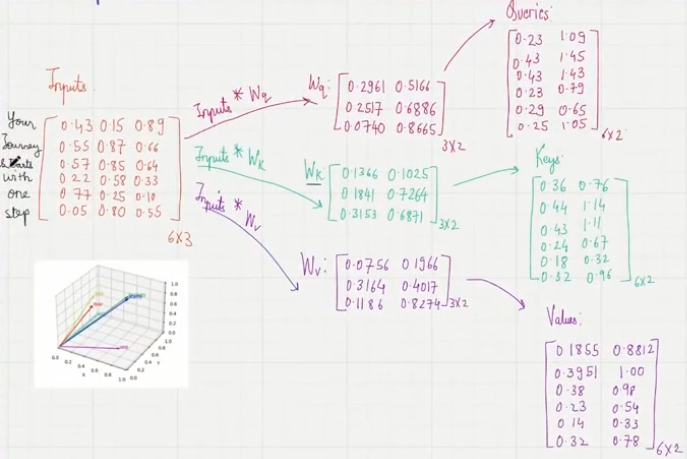

In [3]:
Image("images/stage1_7_kqv_calculation2.png", width=800)

- We have successfully projected the 6 input tokens from 3D to 2D embedding space

### Compute Attention scores

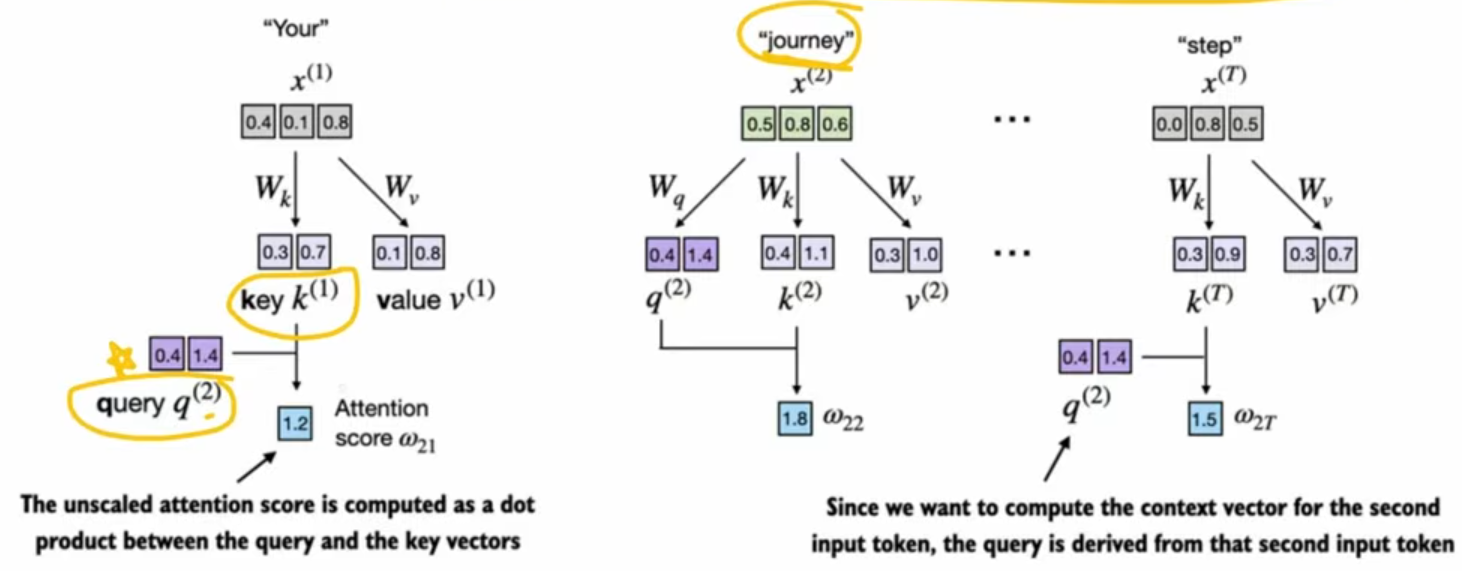

In [4]:
Image("images/stage1_7_attention_score_kqv.png", width=800)

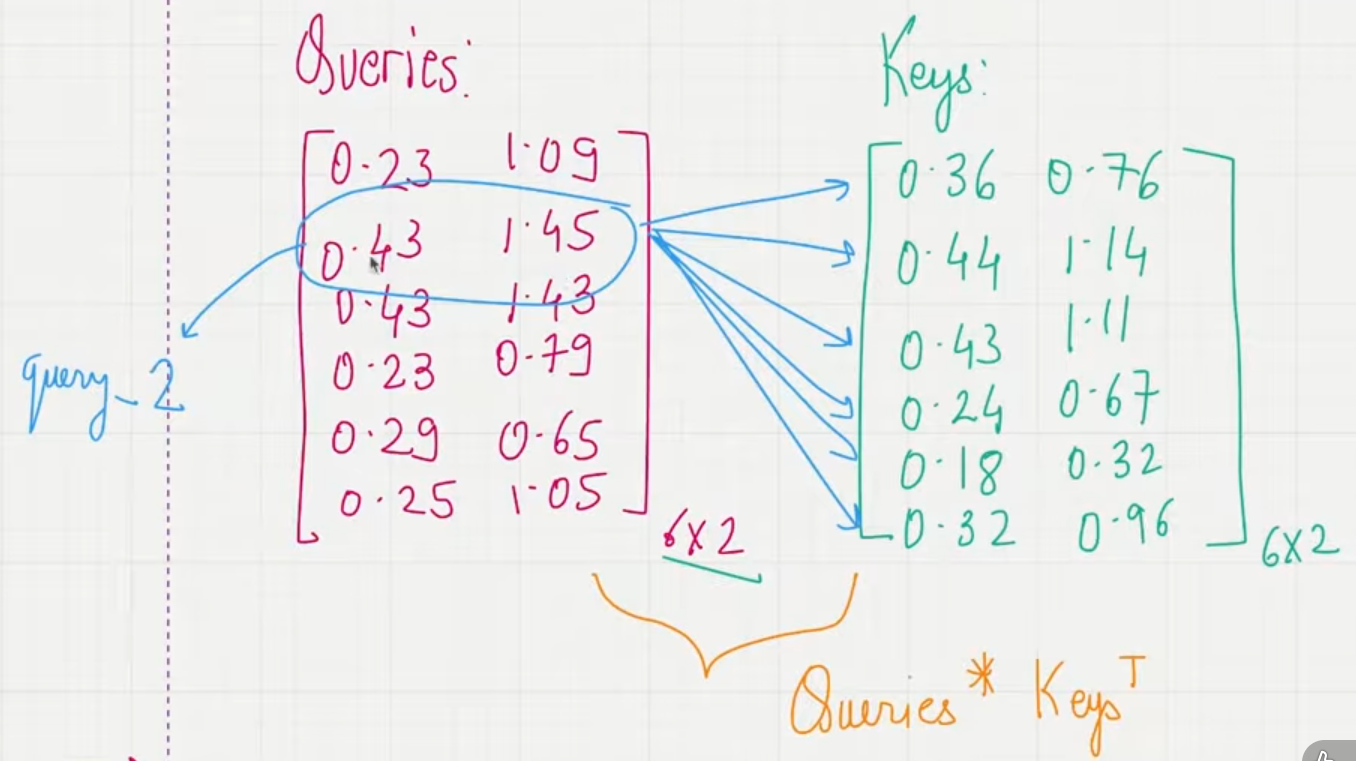

In [7]:
Image("images/stage1_7_kqv_dot_product_2.png", width=500)

Let's compute attention W22

In [77]:
keys

tensor([[0.3669, 0.7646],
        [0.4433, 1.1419],
        [0.4361, 1.1156],
        [0.2408, 0.6706],
        [0.1827, 0.3292],
        [0.3275, 0.9642]])

In [78]:
keys_2 = keys[1]
print("Key vector for 'journey':\n", keys_2)
attn_scores_2 = query_2.dot(keys_2)
print("Attention scores for 'journey':\n", attn_scores_2)

Key vector for 'journey':
 tensor([0.4433, 1.1419])
Attention scores for 'journey':
 tensor(1.8524)


- Let's generalize this calculation for all the inputs

In [79]:
attn_scores_2 = query_2 @ keys.T
print("Attention scores for 'journey' with all keys:\n", attn_scores_2)

Attention scores for 'journey' with all keys:
 tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


Here each attention score represents how much, the word "journey" attends to each word:

 "your", "journey", "starts", "with", "one", "step"

"journey" & "journey" has highest score, as these words are more aligned to each other

In [80]:
attn_scores = queries @ keys.T
print("Attention scores for all words:\n", attn_scores)

Attention scores for all words:
 tensor([[0.9231, 1.3545, 1.3241, 0.7910, 0.4032, 1.1330],
        [1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440],
        [1.2544, 1.8284, 1.7877, 1.0654, 0.5508, 1.5238],
        [0.6973, 1.0167, 0.9941, 0.5925, 0.3061, 0.8475],
        [0.6114, 0.8819, 0.8626, 0.5121, 0.2707, 0.7307],
        [0.8995, 1.3165, 1.2871, 0.7682, 0.3937, 1.0996]])


- But these score are not interpretable

- Hence Normalization is needed

### Compute Attention weights

- We have to scale the score by SQUARE ROOT D -> then ally SOFTMAX function >>>> WHY ?

We compute ATTENTION WEIGHTS by scaling the attention scores and using the Softmax function

- The difference here is that, now we scale the attention scores by dividing them by the square root of the embedding dimension of the keys.

- Note: Square root is exponent of 0.5

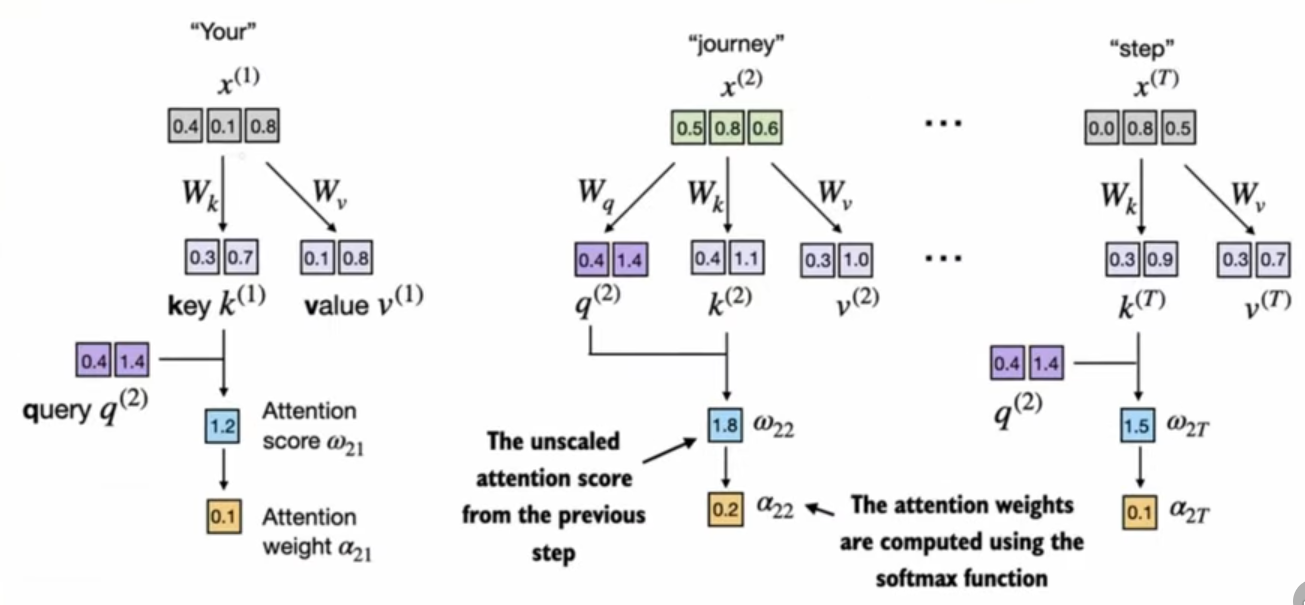

In [6]:
Image("images/stage1_7_kqv_attention_weights.png", width=800)

In [81]:
attn_scores_2

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])

In [82]:
d_k = keys.shape[1]
attn_weights_2 = torch.softmax(attn_scores_2 / (d_k ** 0.5), dim=-1)
print("Attention weights for 'journey':\n", attn_weights_2)
print(d_k)


Attention weights for 'journey':
 tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])
2


In [91]:
attn_weights = torch.softmax(attn_scores / (d_k ** 0.5), dim=-1)
print("Attention weights for all words:\n", attn_weights)

Attention weights for all words:
 tensor([[0.1551, 0.2104, 0.2059, 0.1413, 0.1074, 0.1799],
        [0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820],
        [0.1503, 0.2256, 0.2192, 0.1315, 0.0914, 0.1819],
        [0.1591, 0.1994, 0.1962, 0.1477, 0.1206, 0.1769],
        [0.1610, 0.1949, 0.1923, 0.1501, 0.1265, 0.1752],
        [0.1557, 0.2092, 0.2048, 0.1419, 0.1089, 0.1794]])


### Why divide by SQRT DIM

##### Reason 1: For stability

The softmax function is sentiive to the magnitudes of its inputs. When the inputs are large, the differences between the exponential values of each input becomes much more pronounced.

This causes the softmax function output to become "peaky", where the highest value receives almost all the probability mass, and the rest receive very little.

In attention mechanism, especially transformer, if the dot product between QUERY and KEY vectors becomes too large, the attention scores can become very large.

This results in very sharp softmax distribution, making the model overly confident in one particular "key".

Such sharp distribution can make learning unstable.


In [83]:
import torch

# define tensor
tensor = torch.tensor([0.1, -0.2, 0.3, -0.2, 0.5])

# apply softmax without scaling
softmax_results = torch.softmax(tensor, dim=-1)
print("Softmax results without scaling:\n", softmax_results)

# sclae the tensor: multiply by 8
scaled_tensor = tensor * 8
softmax_scaled_results = torch.softmax(scaled_tensor, dim=-1)
print("Softmax results with scaling:\n", softmax_scaled_results)

Softmax results without scaling:
 tensor([0.1925, 0.1426, 0.2351, 0.1426, 0.2872])
Softmax results with scaling:
 tensor([0.0326, 0.0030, 0.1615, 0.0030, 0.8000])


- Model can becover over confident in 5th key, as it's value is vaery high "0.8"

#### Reason 2: To make the variance of the DOT Product stable

The dot product of Q & K increases the variance because multiplying two random numbers increases the variance.

The increase in variance grows witht the dimension.

Dividing by SQRT (dimesion) keeps the variance close to 1.

In [85]:
import numpy as np

# function to compute variance before and after scaling
def compute_variance(dim, num_trials=1000):
    dot_products = []
    scaled_dot_products = []
    for _ in range(num_trials):
        # generate random query and key vectors
        query = np.random.randn(dim)
        key = np.random.randn(dim)

        # compute dot product
        dot_product = np.dot(query, key)
        dot_products.append(dot_product)

        # compute scaled dot product
        scaled_dot_product = dot_product / np.sqrt(dim)
        scaled_dot_products.append(scaled_dot_product)

    # compute variance
    variance_before_scaling = np.var(dot_products)
    variance_after_scaling = np.var(scaled_dot_products)

    return variance_before_scaling, variance_after_scaling

# test the function with different dimensions
variance_before_5, variance_after_5 = compute_variance(dim=5)
print(f"Variance before scaling (dim=5): {variance_before_5:.4f}")
print(f"Variance after scaling (dim=5): {variance_after_5:.4f}")

variance_before_50, variance_after_50 = compute_variance(dim=50)
print(f"Variance before scaling (dim=50): {variance_before_50:.4f}")
print(f"Variance after scaling (dim=50): {variance_after_50:.4f}")

Variance before scaling (dim=5): 5.8146
Variance after scaling (dim=5): 1.1629
Variance before scaling (dim=50): 48.2623
Variance after scaling (dim=50): 0.9652


### Compute CONTEXT Vector

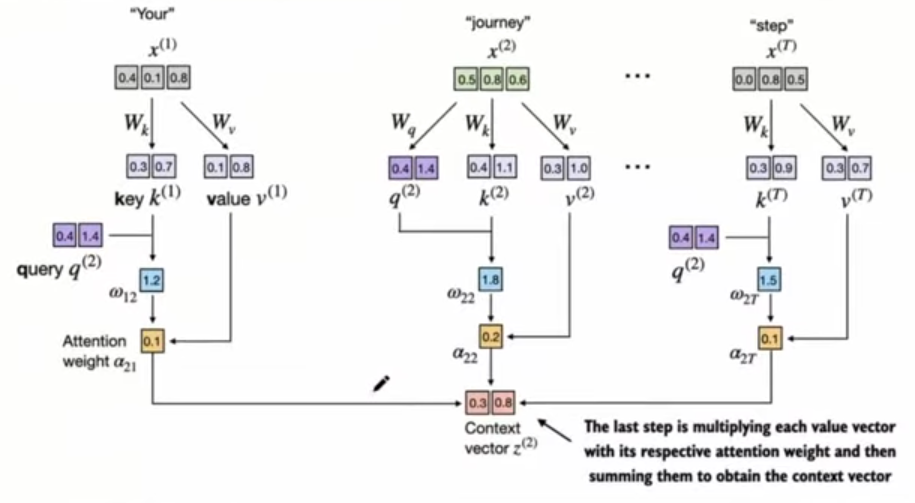

In [8]:

Image("images/stage1_7_kqv_context_vector_gen.png", width=800)

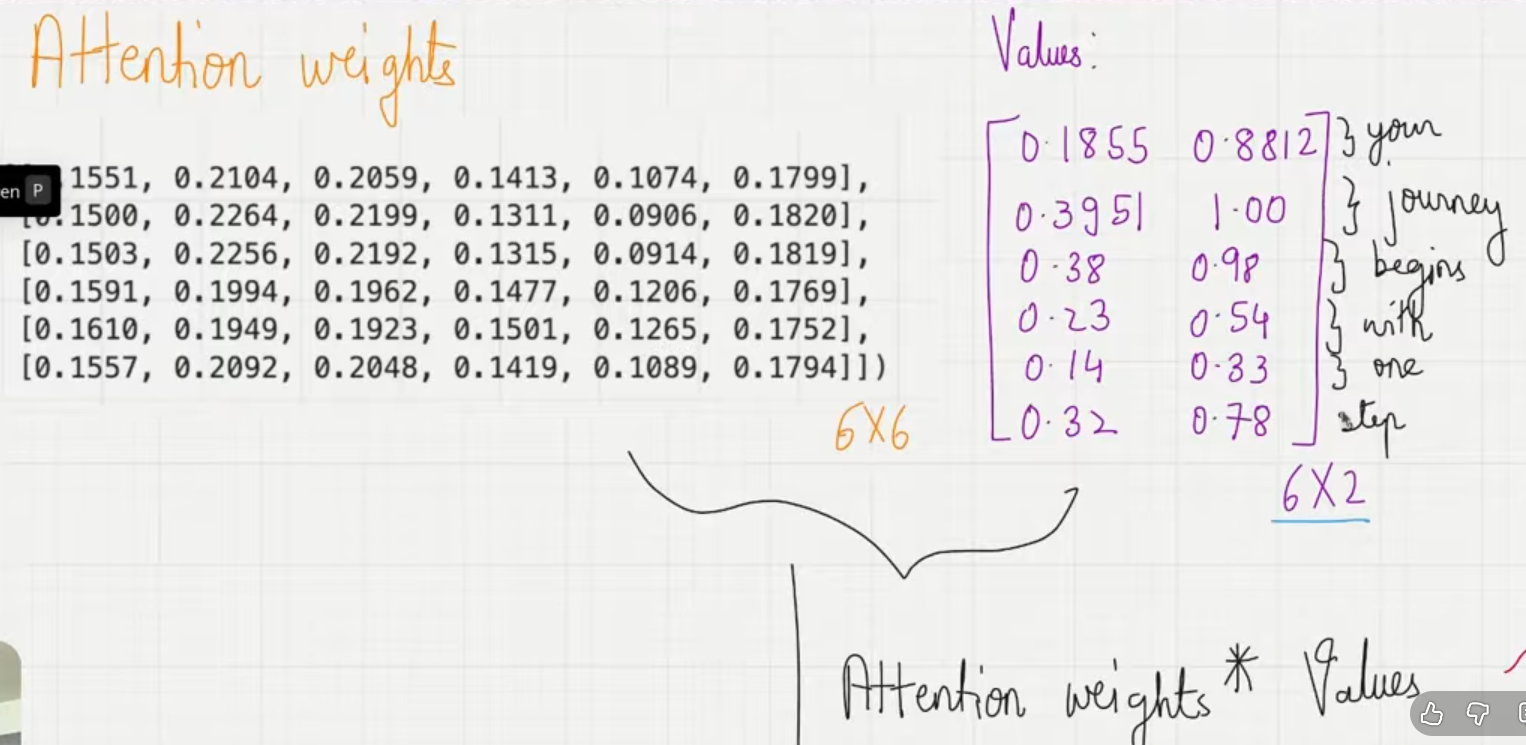

In [9]:

Image("images/stage1_7_kqv_context_vector_calc.png", width=800)

In [90]:
context_vec_2 = attn_weights_2 @ values
print("Context vector for 'journey':\n", context_vec_2)

Context vector for 'journey':
 tensor([0.3061, 0.8210])


- This is context vector for word "journey"

In [93]:
### Create a Python class for the self-attention mechanism that encapsulates the above computations.

import torch.nn as nn

class SelfAttention_v1(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))

    def forward(self, inputs):
        keys = inputs @ self.W_key
        queries = inputs @ self.W_query
        values = inputs @ self.W_value

        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / (keys.shape[-1] ** 0.5), dim=-1)
        context_vectors = attn_weights @ values

        return context_vectors

In [94]:
torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in, d_out)
print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


- Since the input contains 6 embedding vectors, we get a matrix storing the 6 context vectors

#### Improvement

- We can improve the implementation by utilizing Pytorch's nn.Linear_Layers , which effectively performs matrix multiplication when bias units are disabled

- Main advantage is that the nn.Linear_Layers has an optimized weight initialization scheme, contributing to more stable and effective model training

In [96]:
import torch.nn as nn

class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, inputs):
        keys = self.W_key(inputs)
        queries = self.W_query(inputs)
        values = self.W_value(inputs)

        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / (keys.shape[-1] ** 0.5), dim=-1)
        context_vectors = attn_weights @ values

        return context_vectors

In [97]:
torch.manual_seed(789)

sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


### Summary

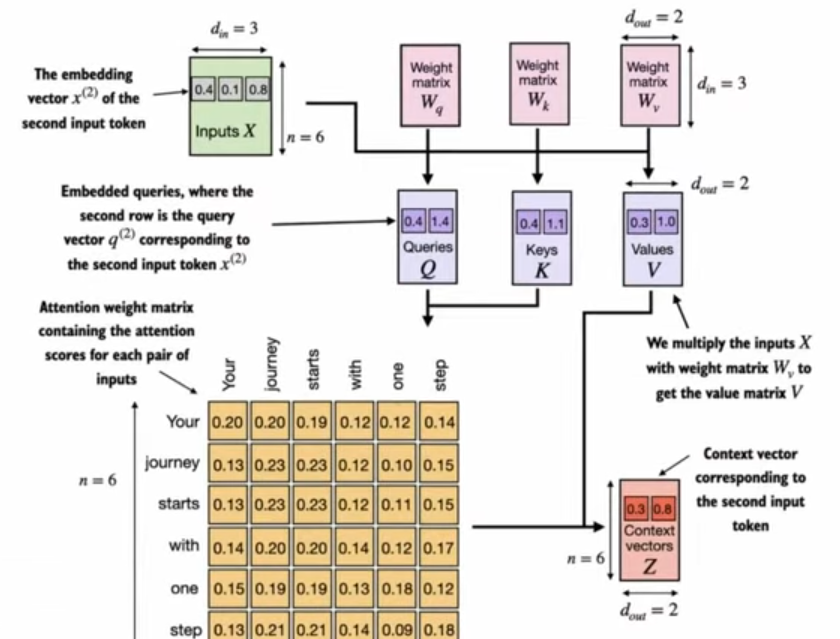

In [11]:

Image("images/stage1_7_kqv_self_attn_train_weights.png", width=600)